<a href="https://colab.research.google.com/github/AndresMontesDeOca/Deep_Learning/blob/main/MONTESDEOCA-ANDRES-DL-TP3-Co24.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Cohorte 24 - 2do bimestre 2026


Este tercer y último TP se debe entregar hasta las **23:59hs del viernes 19 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía que consideren que les haga falta. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/56R6couXZBPDZzfs5)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP3-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

Les recomiendo usar el siguiente código para poder obtener las imágenes fácilmente desde ese link. Pero son libres de descargar las imágenes como mejor les parezca.

## 0. Data & Functions

In [19]:
# Librerias

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gdown
import zipfile
import os
import random
import time
from PIL import Image

from sklearn.metrics import f1_score

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import wandb # Weights and Biases


In [20]:
# ------------------------------------------------------------------
# GENERADOR DE EXPERIMENTOS
# ------------------------------------------------------------------

def ejecutar_bateria_experimentos(nombre_grupo, dataloader_train, dataloader_test, config_extra=None, arquitecturas=None):
    """
    Ejecuta una batería de entrenamientos para las arquitecturas dadas
    y loguea los resultados en Weights & Biases.
    """
    if config_extra is None:
        config_extra = {}

    if arquitecturas is None:
        arquitecturas = {
            "small": [16, 32, 64]
        }

    num_epochs = 100
    patience = 7
    # Obtenemos el learning rate de la configuración o usamos 0.001 por defecto
    learning_rate = config_extra.get("learning_rate", 0.001)

    print(f"Iniciando batería de entrenamientos: {nombre_grupo}...\n")

    for tamano, lista_filtros in arquitecturas.items():
        nombre_corrida = f"{nombre_grupo}_{tamano}"
        print("="*60)
        print(f"EXPERIMENTO: {nombre_corrida} | Arquitectura: {lista_filtros}")
        print("="*60)

        modelo = EmotionCNN(filtros=lista_filtros).to(device)
        criterion = nn.CrossEntropyLoss()

        # Utilizamos la variable learning_rate para el optimizador
        optimizer = optim.Adam(modelo.parameters(), lr=learning_rate, weight_decay=1e-4) # Agrega weight_decay (L2)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

        best_test_loss = float('inf')
        epochs_no_improve = 0
        best_epoch = 0
        best_metrics = {}
        run_metrics_history = []

        # Unificar configuración base con la extra
        config_wandb = {
            "epochs": num_epochs,
            "patience": patience,
            "learning_rate": learning_rate,
            "filtros": lista_filtros,
            "batch_size": 64,
            "oversampling": True,
            "grupo": nombre_grupo
        }
        config_wandb.update(config_extra)

        wandb.init(
            project="tp3-clasificador-emociones",
            name=nombre_corrida,
            group=nombre_grupo,
            config=config_wandb
        )

        for epoch in range(num_epochs):
            start_time = time.time()

            # --- FASE DE ENTRENAMIENTO ---
            modelo.train()
            running_loss = 0.0
            correct_train = 0
            total_train = 0
            all_train_preds = []
            all_train_labels = []

            for inputs, labels in dataloader_train:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = modelo(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_train += labels.size(0)
                correct_train += (predicted == labels).sum().item()

                all_train_preds.extend(predicted.cpu().numpy())
                all_train_labels.extend(labels.cpu().numpy())

            epoch_train_loss = running_loss / len(dataloader_train.dataset)
            epoch_train_acc = correct_train / total_train
            epoch_train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')

            # --- FASE DE TEST ---
            modelo.eval()
            running_test_loss = 0.0
            correct_test = 0
            total_test_loop = 0
            all_test_preds = []
            all_test_labels = []

            with torch.no_grad():
                for inputs, labels in dataloader_test:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = modelo(inputs)
                    loss = criterion(outputs, labels)

                    running_test_loss += loss.item() * inputs.size(0)
                    _, predicted = torch.max(outputs.data, 1)
                    total_test_loop += labels.size(0)
                    correct_test += (predicted == labels).sum().item()

                    all_test_preds.extend(predicted.cpu().numpy())
                    all_test_labels.extend(labels.cpu().numpy())

            epoch_test_loss = running_test_loss / len(dataloader_test.dataset)
            epoch_test_acc = correct_test / total_test_loop
            epoch_test_f1 = f1_score(all_test_labels, all_test_preds, average='macro')

            # Actualiza el learning rate si no hay mejoras
            scheduler.step(epoch_test_loss)

            end_time = time.time()
            print(f"Ep {epoch+1:02d} | Tiempo: {end_time - start_time:.1f}s | Tr_Loss: {epoch_train_loss:.4f} | Tr_Acc: {epoch_train_acc:.4f} | Te_Loss: {epoch_test_loss:.4f} | Te_Acc: {epoch_test_acc:.4f} | Te_F1: {epoch_test_f1:.4f}")

            # Guardamos las métricas temporalmente (SIN LOGUEAR AÚN)
            metricas_epoca = {
                "epoch": epoch + 1,
                "train_loss": round(epoch_train_loss, 2),
                "train_acc": round(epoch_train_acc, 2),
                "train_f1_macro": round(epoch_train_f1, 2),
                "test_loss": round(epoch_test_loss, 2),
                "test_acc": round(epoch_test_acc, 2),
                "test_f1_macro": round(epoch_test_f1, 2)
            }
            run_metrics_history.append(metricas_epoca)

            # --- EARLY STOPPING ---
            if epoch_test_loss < best_test_loss:
                best_test_loss = epoch_test_loss
                epochs_no_improve = 0
                best_epoch = epoch + 1
                best_metrics = metricas_epoca
                torch.save(modelo.state_dict(), f'best_model_{nombre_corrida}.pth')
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f"-> EarlyStopping disparado tras {epoch+1} épocas.")
                    break

        # --- FINALIZACIÓN DE LA CORRIDA ---
        print(f"\nCargando los pesos del mejor modelo (Época {best_epoch}) para {nombre_corrida}...")
        modelo.load_state_dict(torch.load(f'best_model_{nombre_corrida}.pth'))

        print(f"Logueando métricas en W&B SOLAMENTE hasta la mejor época ({best_epoch})...")
        for metricas in run_metrics_history[:best_epoch]:
            wandb.log(metricas)

        if wandb.run is not None:
            # Actualizar el summary del run con los mejores valores
            for key, val in best_metrics.items():
                wandb.run.summary[key] = val

            # Subir los pesos del modelo a wandb
            wandb.save(f'best_model_{nombre_corrida}.pth')

        wandb.finish()
        print(f"¡Entrenamiento de {nombre_corrida} finalizado!\n")

    print(f"¡TODOS LOS EXPERIMENTOS DE {nombre_grupo} HAN FINALIZADO!")

In [21]:
url = "https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT"
output = "archivo.zip"

gdown.download(url, output, quiet=False)

destino = "datos_zip"
os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

DATASET_ROOT_TRAIN = '/content/datos_zip/dataset_emociones/train'
DATASET_ROOT_TEST  = '/content/datos_zip/dataset_emociones/validation' # Lo usaremos como TEST

Downloading...
From (original): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT
From (redirected): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT&confirm=t&uuid=b2defa37-c6e4-4be4-b78b-cc84ca9706d7
To: /content/archivo.zip
100%|██████████| 40.0M/40.0M [00:00<00:00, 71.6MB/s]


In [22]:
# Weights and Biases

# !pip install wandb -qU

import wandb
from google.colab import userdata

wandb_key = userdata.get('WANDB_API_KEY')
wandb.login(key=wandb_key)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


False

In [23]:
# Analisis Distribucion de clases

print("--- TRAIN ---")
train_counts = {}
for clase in sorted(os.listdir(DATASET_ROOT_TRAIN)):
    ruta_clase = os.path.join(DATASET_ROOT_TRAIN, clase)
    if os.path.isdir(ruta_clase):
        train_counts[clase] = len(os.listdir(ruta_clase))

total_train = sum(train_counts.values())
for clase, cantidad in train_counts.items():
    porcentaje = (cantidad / total_train) * 100 if total_train > 0 else 0
    print(f"Clase '{clase}': {cantidad} imágenes ({porcentaje:.2f}%)")
print(f"Total Train: {total_train}\n")

print("--- TEST ---")
test_counts = {}
for clase in sorted(os.listdir(DATASET_ROOT_TEST)):
    ruta_clase = os.path.join(DATASET_ROOT_TEST, clase)
    if os.path.isdir(ruta_clase):
        test_counts[clase] = len(os.listdir(ruta_clase))

total_test = sum(test_counts.values())
for clase, cantidad in test_counts.items():
    porcentaje = (cantidad / total_test) * 100 if total_test > 0 else 0
    print(f"Clase '{clase}': {cantidad} imágenes ({porcentaje:.2f}%)")
print(f"Total Test: {total_test}")

--- TRAIN ---
Clase 'alegria': 4772 imágenes (38.89%)
Clase 'disgusto': 717 imágenes (5.84%)
Clase 'enojo': 705 imágenes (5.75%)
Clase 'miedo': 281 imágenes (2.29%)
Clase 'seriedad': 2524 imágenes (20.57%)
Clase 'sorpresa': 1290 imágenes (10.51%)
Clase 'tristeza': 1982 imágenes (16.15%)
Total Train: 12271

--- TEST ---
Clase 'alegria': 1185 imágenes (38.62%)
Clase 'disgusto': 160 imágenes (5.22%)
Clase 'enojo': 162 imágenes (5.28%)
Clase 'miedo': 74 imágenes (2.41%)
Clase 'seriedad': 680 imágenes (22.16%)
Clase 'sorpresa': 329 imágenes (10.72%)
Clase 'tristeza': 478 imágenes (15.58%)
Total Test: 3068


- Dividido 80/20, bien estratificado por clase
- La distribucion de las clases no es homogenea

## 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html



- **Class Imbalance**: Utilicé `WeightedRandomSampler` para hacer oversampling de las clases minoritarias durante el entrenamiento.
- **Escala de grises (1 Canal)**: Convertí todo a blanco y negro. El color no me aporta información extra para clasificar emociones y me permite diseñar una red más liviana y rápida de entrenar.
- **Normalización**: Estandaricé los tensores usando la media y desviación estándar calculadas sobre mi set de train (previamente calculado).
- **Horizontal Flip**: `RandomHorizontalFlip` ya que los rostros son simétricos respecto a las expresiones.
- **Rotación**: Sumé rotaciones leves (`RandomRotation`) para forzar al modelo a ser invariante a la inclinación de la cabeza (muy común en fotos reales).
- **Color Jitter**: Agregué variaciones de brillo y contraste (`ColorJitter`) para que la red aprenda a generalizar bajo distintas condiciones de iluminación.
- **Gaussian Blur**: Apliqué desenfoque gaussiano (`GaussianBlur`) para simular fotos movidas o cámaras fuera de foco. Esto evita que el modelo dependa de bordes perfectos y lo hace más robusto ante imágenes de menor calidad. Habia bastantes en el set de train.
- **Perspectiva Aleatoria**: Sumé `RandomPerspective` para simular distintos ángulos.
- **Traslación y Escala (Affine)**: Agregué `RandomAffine` con ligeras traslaciones y zoom.
- **Oclusión (Random Erasing)**: Apliqué `RandomErasing` para simular rostros parcialmente tapados, obligando a la red a extraer características de todo el rostro y no depender de un solo rasgo.

### 1.1 Visializador de Imagenes

--- DICCIONARIO DE CLASES ---
0: Aleatorio
1: Alegria
2: Disgusto
3: Enojo
4: Miedo
5: Seriedad
6: Sorpresa
7: Tristeza
----------------------------------------
Opción 0 (o inválida). Clase elegida al azar.
--- METADATA DE LAS IMÁGENES (ALEGRIA) ---
[1] Archivo: train_05236_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[2] Archivo: train_03675_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[3] Archivo: train_08167_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[4] Archivo: train_03292_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG


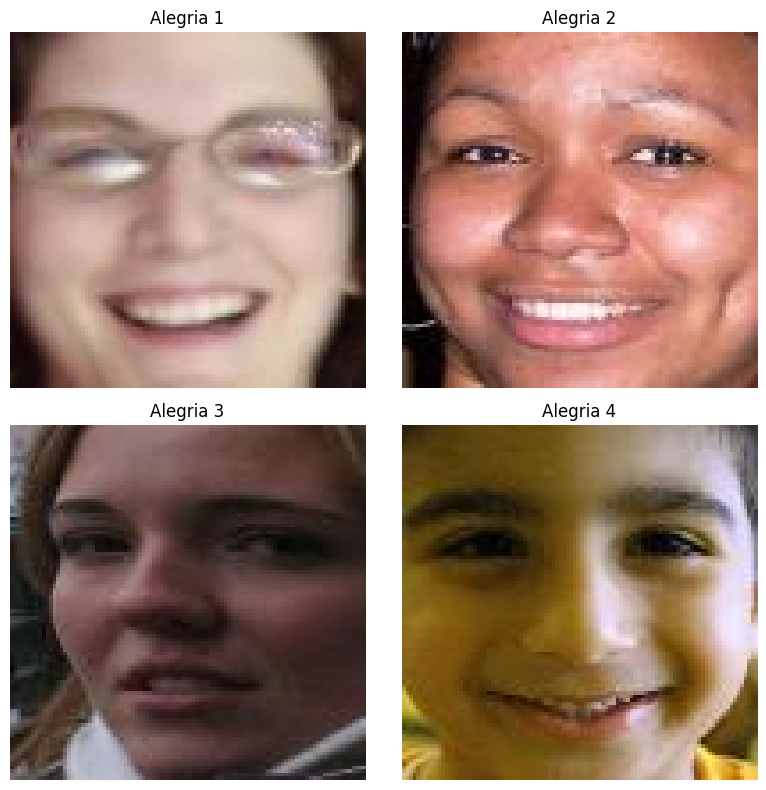

In [24]:
# VISUALIZADOR
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Clases ordenadas alfabéticamente
clases = sorted(os.listdir(DATASET_ROOT_TRAIN))

# Crear y mostrar el diccionario de opciones
diccionario_clases = {i+1: c for i, c in enumerate(clases)}
print("--- DICCIONARIO DE CLASES ---")
print("0: Aleatorio")
for k, v in diccionario_clases.items():
    print(f"{k}: {v.capitalize()}")
print("-" * 40)

# @markdown Ingresa el número de la clase que deseas visualizar:
opcion_clase = 0 # @param {type:"integer"}

if 1 <= opcion_clase <= len(clases):
    clase_seleccionada = diccionario_clases[opcion_clase]
else:
    clase_seleccionada = random.choice(clases)
    print("Opción 0 (o inválida). Clase elegida al azar.")

ruta_clase = os.path.join(DATASET_ROOT_TRAIN, clase_seleccionada)
imagenes_disponibles = [f for f in os.listdir(ruta_clase) if os.path.isfile(os.path.join(ruta_clase, f))]

if imagenes_disponibles:
    # Seleccionar hasta 4 imágenes aleatorias
    cantidad_a_mostrar = min(4, len(imagenes_disponibles))
    imagenes_random = random.sample(imagenes_disponibles, cantidad_a_mostrar)

    print(f"--- METADATA DE LAS IMÁGENES ({clase_seleccionada.upper()}) ---")

    # Crear una cuadrícula de 2x2
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    axes = axes.flatten() # Aplanar para iterar fácilmente

    for i in range(4):
        if i < cantidad_a_mostrar:
            imagen_random = imagenes_random[i]
            ruta_imagen = os.path.join(ruta_clase, imagen_random)
            img = Image.open(ruta_imagen)

            print(f"[{i+1}] Archivo: {imagen_random} | Resolución: {img.size} | Modo: {img.mode} | Formato: {img.format}")

            # Mostrar la imagen con matplotlib
            if img.mode == 'L':
                axes[i].imshow(img, cmap='gray')
            else:
                axes[i].imshow(img)

            axes[i].set_title(f"{clase_seleccionada.capitalize()} {i+1}")

        axes[i].axis('off') # Ocultar ejes incluso si no hay imagen en ese espacio

    plt.tight_layout()
    plt.show()
else:
    print(f"No se encontraron imágenes en la clase {clase_seleccionada}.")

- Imagenes de rostros en primer plano
- Todas las imágenes son 100x100 pixels, 3ch(RGB) y formato JPEG
- Algunas en escalas de grises
- Algunas con el lienzo que no es de 100*100

### 1.2 Transformaciones y Data Agumentation

In [25]:
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import torch
import numpy as np

print("--- 1. ESTADÍSTICAS PARA 1 CANAL (ESCALA DE GRISES) ---")
# Valores pre-calculados para el dataset de entrenamiento (1 canal)
MEAN = [0.4816167652606964]
STD = [0.5369674563407898]

print(f"Mean (Media) hardcodeada: {MEAN}")
print(f"Std (Desviación) hardcodeada: {STD}\n")

print("--- 2. CREANDO DATALOADERS FINALES ---")
# Transformaciones finales incluyendo la normalización
transforms_norm = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.Grayscale(num_output_channels=1), # <-- Aseguramos 1 canal
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)     # <-- Normalización con valores fijos
])

# Datasets finales únicos
train_dataset = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_norm)
test_dataset = datasets.ImageFolder(root=DATASET_ROOT_TEST, transform=transforms_norm)

# Calcular Pesos para el Sampler (Oversampling)
targets = train_dataset.targets
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in targets]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(targets), replacement=True)

# Crear los DataLoaders Finales
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Imágenes para entrenamiento: {len(train_dataset)} -> Batches: {len(train_loader)}")
print(f"Imágenes para test: {len(test_dataset)} -> Batches: {len(test_loader)}")

--- 1. ESTADÍSTICAS PARA 1 CANAL (ESCALA DE GRISES) ---
Mean (Media) hardcodeada: [0.4816167652606964]
Std (Desviación) hardcodeada: [0.5369674563407898]

--- 2. CREANDO DATALOADERS FINALES ---
Imágenes para entrenamiento: 12271 -> Batches: 192
Imágenes para test: 3068 -> Batches: 48


## 2 Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional con PyTorch, **sin usar modelos pre-entrenados**.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

In [26]:
import numpy as np
import torch.nn as nn
import torch

# Bloque de convolución para emplear en la red
def conv_block(c_in, c_out, k=3, p=1, s=1, pk=2):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, k, padding=p, stride=s),
        nn.BatchNorm2d(c_out), # <-- Ayuda a estabilizar y acelera el entrenamiento
        nn.ReLU(),
        nn.MaxPool2d(pk)
    )

class EmotionCNN(nn.Module):
    def __init__(self, filtros=[16, 32, 64]):
        super(EmotionCNN, self).__init__()

        layers = []
        in_channels = 1 # Imágenes en escala de grises (1 canal)

        if len(filtros) > 0:
            # EXPERIMENTO 1: Primera capa con Kernel 5x5 y Padding 2 para capturar patrones globales
            layers.append(conv_block(in_channels, filtros[0], k=5, p=2))
            in_channels = filtros[0]

            # Resto de las capas convolucionales con Kernel 3x3 y Padding 1 (estándar)
            for out_channels in filtros[1:]:
                layers.append(conv_block(in_channels, out_channels, k=3, p=1))
                in_channels = out_channels

        self.features = nn.Sequential(*layers)

        # Calcular automáticamente el tamaño de la imagen tras los MaxPool2d
        dim = 100
        for _ in filtros:
            dim = dim // 2

        flatten_size = filtros[-1] * dim * dim

        # Clasificador ORIGINAL (Revertido para aislar el experimento del Kernel)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 7)      # 7 clases de emociones
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\nModelo base listo para instanciar en el dispositivo: {device}")
print("Arquitectura actualizada: EXPERIMENTO 1 - Solo Kernel 5x5 en la primera capa.")


Modelo base listo para instanciar en el dispositivo: cuda
Arquitectura actualizada para recibir 1 solo canal (Grayscale).


## 2.1 Baseline (1ch, WRS, Norm, small)

In [27]:
# ==================================================================
# EJECUCIÓN DEL NUEVO BASELINE
# ==================================================================

# config_baseline = {
#     "data_augmentation": False,
#     "da_technique": "None (Only Norm + 1CH)"
# }
#
# ejecutar_bateria_experimentos(
#     nombre_grupo="Baseline_1CH_WRS",
#     dataloader_train=train_loader,
#     dataloader_test=test_loader,
#     config_extra=config_baseline
# )

## 2.2 Data Augmentation: RandomHorizontalFlip

In [28]:
# # ==================================================================
# # 2.2 Data Augmentation: RandomHorizontalFlip
# # ==================================================================

# print("--- PREPARANDO DATALOADER CON HORIZONTAL FLIP ---")

# # 1. Definimos las transformaciones AÑADIENDO RandomHorizontalFlip
# transforms_hflip = transforms.Compose([
#     transforms.Resize((100, 100)),
#     transforms.RandomHorizontalFlip(p=0.5),      # <-- NUEVA TRANSFORMACIÓN
#     transforms.Grayscale(num_output_channels=1),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=MEAN, std=STD)
# ])

# # 2. Aplicamos la transformación SOLO al dataset de entrenamiento
# train_dataset_hflip = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_hflip)

# # 3. Creamos el nuevo DataLoader de entrenamiento manteniendo el mismo Sampler para las clases
# train_loader_hflip = DataLoader(train_dataset_hflip, batch_size=batch_size, sampler=sampler)

# # 4. Configuración extra para guardar en Weights & Biases
# config_hflip = {
#     "data_augmentation": True,
#     "da_technique": "RandomHorizontalFlip (p=0.5)"
# }

# # 5. Definimos las 3 arquitecturas para probar en este experimento
# arquitecturas_todas = {
#     "small": [16, 32, 64],
#     "mid": [32, 64, 128],
#     "large": [64, 128, 256]
# }

# # 6. Ejecutamos pasándole el nuevo loader de train y el loader de test original
# ejecutar_bateria_experimentos(
#     nombre_grupo="Exp_HorizontalFlip",
#     dataloader_train=train_loader_hflip,
#     dataloader_test=test_loader,  # <-- El de validación/test NO se altera
#     config_extra=config_hflip,
#     arquitecturas=arquitecturas_todas
# )

## 2.3 Data Augmentation: RandomRotation

In [29]:
# # ==================================================================
# # 2.3 Data Augmentation: RandomRotation
# # ==================================================================

# print("--- PREPARANDO DATALOADERS CON RANDOM ROTATION ---")

# # Definimos los grados que queremos probar
# grados_a_probar = [10, 20, 30]

# # Fijamos la arquitectura solo a 'small'
# arq_small = {
#     "small": [16, 32, 64]
# }

# for grados in grados_a_probar:
#     print(f"\n>>> INICIANDO PRUEBA CON ROTACIÓN: ±{grados} GRADOS <<<")

#     # 1. Definimos las transformaciones AÑADIENDO RandomRotation
#     transforms_rotation = transforms.Compose([
#         transforms.Resize((100, 100)),
#         transforms.RandomRotation(degrees=grados),       # <-- VARIAMOS LOS GRADOS
#         transforms.Grayscale(num_output_channels=1),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=MEAN, std=STD)
#     ])

#     # 2. Aplicamos la transformación SOLO al dataset de entrenamiento
#     train_dataset_rotation = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_rotation)

#     # 3. Creamos el nuevo DataLoader de entrenamiento
#     train_loader_rotation = DataLoader(train_dataset_rotation, batch_size=batch_size, sampler=sampler)

#     # 4. Configuración extra para guardar en Weights & Biases
#     config_rotation = {
#         "data_augmentation": True,
#         "da_technique": f"RandomRotation (degrees={grados})"
#     }

#     # 5. Ejecutamos pasándole el nuevo loader de train y el loader de test original
#     ejecutar_bateria_experimentos(
#         nombre_grupo=f"Exp_RandomRotation_{grados}deg",
#         dataloader_train=train_loader_rotation,
#         dataloader_test=test_loader,  # <-- El de validación/test NO se altera
#         config_extra=config_rotation,
#         arquitecturas=arq_small
#     )

## 2.4 Data Augmentation: ColorJitter (Brillo y Contraste)

In [30]:
# # ==================================================================
# # 2.4 Data Augmentation: ColorJitter
# # ==================================================================

# print("--- PREPARANDO DATALOADERS CON COLOR JITTER ---")

# # Definimos las intensidades (10%, 20% y 30% de variación)
# intensidades_a_probar = [0.1, 0.2, 0.3]

# for intensidad in intensidades_a_probar:
#     print(f"\n>>> INICIANDO PRUEBA CON COLOR JITTER: Intensidad {intensidad} <<<")

#     # Ajustamos la key de la arquitectura para diferenciar el nombre del run
#     arq_small = {
#         f"small_{intensidad}": [16, 32, 64]
#     }

#     # 1. Definimos las transformaciones AÑADIENDO ColorJitter
#     transforms_jitter = transforms.Compose([
#         transforms.Resize((100, 100)),
#         transforms.ColorJitter(brightness=intensidad, contrast=intensidad), # <-- VARIAMOS LA ILUMINACIÓN
#         transforms.Grayscale(num_output_channels=1),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=MEAN, std=STD)
#     ])

#     # 2. Aplicamos la transformación SOLO al dataset de entrenamiento
#     train_dataset_jitter = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_jitter)

#     # 3. Creamos el nuevo DataLoader de entrenamiento
#     train_loader_jitter = DataLoader(train_dataset_jitter, batch_size=batch_size, sampler=sampler)

#     # 4. Configuración extra para guardar en Weights & Biases
#     config_jitter = {
#         "data_augmentation": True,
#         "da_technique": f"ColorJitter (b={intensidad}, c={intensidad})"
#     }

#     # 5. Ejecutamos pasándole el nuevo loader de train y el loader de test original
#     ejecutar_bateria_experimentos(
#         nombre_grupo="Color_Jitter",  # <-- MISMO GRUPO PARA TODAS LAS INTENSIDADES
#         dataloader_train=train_loader_jitter,
#         dataloader_test=test_loader,  # <-- El de validación/test NO se altera
#         config_extra=config_jitter,
#         arquitecturas=arq_small
#     )


## 2.5 Data Augmentation: Gaussian Blur (Imágenes movidas/desenfocadas)

In [31]:
# # ==================================================================
# # 2.5 Data Augmentation: GaussianBlur
# # ==================================================================

# print("--- PREPARANDO DATALOADERS CON GAUSSIAN BLUR (IMÁGENES MOVIDAS) ---")

# # Definimos los tamaños del kernel a probar (mientras más grande, más borroso. Deben ser impares)
# kernels_a_probar = [3, 5, 7]

# for kernel in kernels_a_probar:
#     print(f"\n>>> INICIANDO PRUEBA CON BLUR: Kernel {kernel}x{kernel} <<<")

#     # Ajustamos la key de la arquitectura para diferenciar el nombre del run
#     arq_small = {
#         f"small_k{kernel}": [16, 32, 64]
#     }

#     # 1. Definimos las transformaciones AÑADIENDO GaussianBlur
#     transforms_blur = transforms.Compose([
#         transforms.Resize((100, 100)),
#         transforms.GaussianBlur(kernel_size=kernel), # <-- SIMULAMOS EL DESENFOQUE/MOVIMIENTO
#         transforms.Grayscale(num_output_channels=1),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=MEAN, std=STD)
#     ])

#     # 2. Aplicamos la transformación SOLO al dataset de entrenamiento
#     train_dataset_blur = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_blur)

#     # 3. Creamos el nuevo DataLoader de entrenamiento
#     train_loader_blur = DataLoader(train_dataset_blur, batch_size=batch_size, sampler=sampler)

#     # 4. Configuración extra para guardar en Weights & Biases
#     config_blur = {
#         "data_augmentation": True,
#         "da_technique": f"GaussianBlur (kernel_size={kernel})"
#     }

#     # 5. Ejecutamos pasándole el nuevo loader de train y el loader de test original
#     ejecutar_bateria_experimentos(
#         nombre_grupo="Gaussian_Blur",  # <-- MISMO GRUPO PARA TODAS LAS INTENSIDADES
#         dataloader_train=train_loader_blur,
#         dataloader_test=test_loader,  # <-- El de validación/test NO se altera
#         config_extra=config_blur,
#         arquitecturas=arq_small
#     )


## 2.6 Data Augmentation: Random Perspective

In [32]:
# # ==================================================================
# # 2.6 Data Augmentation: RandomPerspective
# # ==================================================================

# print("--- PREPARANDO DATALOADERS CON RANDOM PERSPECTIVE ---")

# # Definimos las escalas de distorsión a probar (valores bajos por ser rostros en primer plano)
# escalas_a_probar = [0.1, 0.2, 0.3]

# for escala in escalas_a_probar:
#     print(f"\n>>> INICIANDO PRUEBA CON PERSPECTIVA: Distorsión {escala} <<<")

#     # Ajustamos la key de la arquitectura para diferenciar el nombre del run
#     arq_small = {
#         f"small_dist{escala}": [16, 32, 64]
#     }

#     # 1. Definimos las transformaciones AÑADIENDO RandomPerspective
#     # p=1.0 fuerza la transformación para medir su impacto exacto en el experimento
#     transforms_perspective = transforms.Compose([
#         transforms.Resize((100, 100)),
#         transforms.RandomPerspective(distortion_scale=escala, p=1.0), # <-- SIMULAMOS CAMBIO DE ÁNGULO
#         transforms.Grayscale(num_output_channels=1),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=MEAN, std=STD)
#     ])

#     # 2. Aplicamos la transformación SOLO al dataset de entrenamiento
#     train_dataset_perspective = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_perspective)

#     # 3. Creamos el nuevo DataLoader de entrenamiento
#     train_loader_perspective = DataLoader(train_dataset_perspective, batch_size=batch_size, sampler=sampler)

#     # 4. Configuración extra para guardar en Weights & Biases
#     config_perspective = {
#         "data_augmentation": True,
#         "da_technique": f"RandomPerspective (scale={escala})"
#     }

#     # 5. Ejecutamos pasándole el nuevo loader de train y el loader de test original
#     ejecutar_bateria_experimentos(
#         nombre_grupo="Random_Perspective",  # <-- MISMO GRUPO PARA TODAS LAS ESCALAS
#         dataloader_train=train_loader_perspective,
#         dataloader_test=test_loader,  # <-- El de validación/test NO se altera
#         config_extra=config_perspective,
#         arquitecturas=arq_small
#     )


## 2.7 Data Augmentation: Random Affine (Traslación y Escala)

In [33]:
# # ==================================================================
# # 2.7 Data Augmentation: RandomAffine
# # ==================================================================

# print("--- PREPARANDO DATALOADERS CON RANDOM AFFINE ---")

# # Probaremos distintas intensidades de traslación (1%, 3% y 5% del tamaño de la imagen)
# traslaciones_a_probar = [0.01, 0.03, 0.05]

# for traslacion in traslaciones_a_probar:
#     print(f"\n>>> INICIANDO PRUEBA CON AFFINE: Traslación {int(traslacion*100)}% <<<")

#     # Ajustamos la key de la arquitectura para diferenciar el nombre del run
#     arq_small = {
#         f"small_affine_{traslacion}": [16, 32, 64]
#     }

#     # 1. Definimos las transformaciones AÑADIENDO RandomAffine
#     # Mantenemos degrees=0 porque ya probamos rotación sola.
#     # scale=(0.9, 1.1) aplica un leve zoom in/out aleatorio del 10%.
#     transforms_affine = transforms.Compose([
#         transforms.Resize((100, 100)),
#         transforms.RandomAffine(degrees=0, translate=(traslacion, traslacion), scale=(0.9, 1.1)),
#         transforms.Grayscale(num_output_channels=1),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=MEAN, std=STD)
#     ])

#     # 2. Aplicamos la transformación SOLO al dataset de entrenamiento
#     train_dataset_affine = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_affine)

#     # 3. Creamos el nuevo DataLoader de entrenamiento
#     train_loader_affine = DataLoader(train_dataset_affine, batch_size=batch_size, sampler=sampler)

#     # 4. Configuración extra para guardar en Weights & Biases
#     config_affine = {
#         "data_augmentation": True,
#         "da_technique": f"RandomAffine (trans={traslacion}, scale=0.9-1.1)"
#     }

#     # 5. Ejecutamos pasándole el nuevo loader de train y el loader de test original
#     ejecutar_bateria_experimentos(
#         nombre_grupo="Random_Affine",
#         dataloader_train=train_loader_affine,
#         dataloader_test=test_loader,
#         config_extra=config_affine,
#         arquitecturas=arq_small
#     )


## 2.8 Data Augmentation: Random Erasing (Oclusión)

In [34]:
# # ==================================================================
# # 2.8 Data Augmentation: RandomErasing (Oclusión)
# # ==================================================================

# print("--- PREPARANDO DATALOADERS CON RANDOM ERASING ---")

# # Probaremos distintas probabilidades de que aparezca el parche (40%, 50% y 60%)
# probabilidades_a_probar = [0.4, 0.5, 0.6]

# for prob in probabilidades_a_probar:
#     print(f"\n>>> INICIANDO PRUEBA CON ERASING: Probabilidad {int(prob*100)}% <<<")

#     # Ajustamos la key de la arquitectura para diferenciar el nombre del run
#     arq_small = {
#         f"small_erasing_{prob}": [16, 32, 64]
#     }

#     # 1. Definimos las transformaciones AÑADIENDO RandomErasing
#     # NOTA IMPORTANTE: RandomErasing trabaja sobre tensores, DEBE ir después de ToTensor()
#     transforms_erasing = transforms.Compose([
#         transforms.Resize((100, 100)),
#         transforms.Grayscale(num_output_channels=1),
#         transforms.ToTensor(),
#         transforms.RandomErasing(p=prob, scale=(0.02, 0.1)), # <-- Parche aleatorio que tapa entre 2% y 10% de la imagen
#         transforms.Normalize(mean=MEAN, std=STD)
#     ])

#     # 2. Aplicamos la transformación SOLO al dataset de entrenamiento
#     train_dataset_erasing = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_erasing)

#     # 3. Creamos el nuevo DataLoader de entrenamiento
#     train_loader_erasing = DataLoader(train_dataset_erasing, batch_size=batch_size, sampler=sampler)

#     # 4. Configuración extra para guardar en Weights & Biases
#     config_erasing = {
#         "data_augmentation": True,
#         "da_technique": f"RandomErasing (p={prob}, scale=0.02-0.1)"
#     }

#     # 5. Ejecutamos pasándole el nuevo loader de train y el loader de test original
#     ejecutar_bateria_experimentos(
#         nombre_grupo="Random_Erasing",
#         dataloader_train=train_loader_erasing,
#         dataloader_test=test_loader,
#         config_extra=config_erasing,
#         arquitecturas=arq_small
#     )


## 3. Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score Macro**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`.


In [ ]:
# ==================================================================
# ENTRENAMIENTO DEL MODELO FINAL CON MEJORES HIPERPARÁMETROS
# ==================================================================
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

print("--- ARMANDO PIPELINE DEL MODELO FINAL ---")

# Parámetros elegidos manualmente
best_rot = 10
best_jitter = 0.3
best_perspective = 0.05
best_affine = 0.05
best_erasing = 0.3

# 1. Definimos las transformaciones combinando todas las ganadoras
transforms_final = transforms.Compose([
    transforms.Resize((100, 100)),

    # Transformaciones espaciales y de color
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=best_rot),
    transforms.ColorJitter(brightness=best_jitter, contrast=best_jitter),
    transforms.RandomPerspective(distortion_scale=best_perspective, p=0.5),
    transforms.RandomAffine(degrees=0, translate=(best_affine, best_affine), scale=(0.9, 1.1)),

    # Conversión a grises y a Tensor
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),

    # Random Erasing (debe ir sobre el Tensor)
    transforms.RandomErasing(p=best_erasing, scale=(0.02, 0.1)),

    # Normalización estadística
    transforms.Normalize(mean=MEAN, std=STD)
])

# 2. Aplicamos al dataset y creamos loader
train_dataset_final = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transforms_final)
train_loader_final = DataLoader(train_dataset_final, batch_size=batch_size, sampler=sampler)

config_final = {
    "data_augmentation": True,
    "da_technique": "Combinacion_Ganadores_Manual",
    "learning_rate": 0.0001,
    "arquitectura_nota": "Kernel 5x5 en capa 1"
}

# 3. Arquitecturas a probar (Solo dejamos la MID para este experimento)
arquitecturas_finales = {
    "final_mid": [32, 64, 128]
}

# 4. Entrenamos la red
ejecutar_bateria_experimentos(
    nombre_grupo="Exp_Arq_Kernel5x5",
    dataloader_train=train_loader_final,
    dataloader_test=test_loader,
    config_extra=config_final,
    arquitecturas=arquitecturas_finales
)

--- ARMANDO PIPELINE DEL MODELO FINAL ---
Iniciando batería de entrenamientos: Modelo_Final_BN...

EXPERIMENTO: Modelo_Final_BN_final_mid | Arquitectura: [32, 64, 128]


Ep 01 | Tiempo: 30.2s | Tr_Loss: 1.8580 | Tr_Acc: 0.2492 | Te_Loss: 1.6911 | Te_Acc: 0.3582 | Te_F1: 0.2821
Ep 02 | Tiempo: 30.1s | Tr_Loss: 1.7216 | Tr_Acc: 0.3199 | Te_Loss: 1.5783 | Te_Acc: 0.4459 | Te_F1: 0.3808
Ep 03 | Tiempo: 30.0s | Tr_Loss: 1.5970 | Tr_Acc: 0.3888 | Te_Loss: 1.2964 | Te_Acc: 0.5290 | Te_F1: 0.4223
Ep 04 | Tiempo: 30.1s | Tr_Loss: 1.4931 | Tr_Acc: 0.4383 | Te_Loss: 1.2856 | Te_Acc: 0.5486 | Te_F1: 0.4633
Ep 05 | Tiempo: 29.9s | Tr_Loss: 1.4248 | Tr_Acc: 0.4643 | Te_Loss: 1.1392 | Te_Acc: 0.5857 | Te_F1: 0.5076
Ep 06 | Tiempo: 29.9s | Tr_Loss: 1.3750 | Tr_Acc: 0.4811 | Te_Loss: 1.1041 | Te_Acc: 0.6004 | Te_F1: 0.5064
Ep 07 | Tiempo: 30.1s | Tr_Loss: 1.3115 | Tr_Acc: 0.5097 | Te_Loss: 1.1010 | Te_Acc: 0.5805 | Te_F1: 0.5097
Ep 08 | Tiempo: 29.9s | Tr_Loss: 1.3055 | Tr_Acc: 0.5111 | Te_Loss: 1.0066 | Te_Acc: 0.6538 | Te_F1: 0.5675
Ep 09 | Tiempo: 30.0s | Tr_Loss: 1.2576 | Tr_Acc: 0.5346 | Te_Loss: 1.0395 | Te_Acc: 0.6098 | Te_F1: 0.5249
Ep 10 | Tiempo: 29.9s | Tr_L

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Ep 56 | Tiempo: 29.2s | Tr_Loss: 0.8768 | Tr_Acc: 0.6791 | Te_Loss: 0.7174 | Te_Acc: 0.7435 | Te_F1: 0.6666
-> EarlyStopping disparado tras 56 épocas.

Cargando los pesos del mejor modelo (Época 49) para Modelo_Final_BN_final_mid...
Logueando métricas en W&B SOLAMENTE hasta la mejor época (49)...


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
test_acc,▁▃▄▄▅▅▆▅▆▆▆▇▇▇▆▆▇▇▇▇▇▇▇▇█▇▇█▇███████████
test_f1_macro,▁▃▄▄▅▅▆▅▆▆▆▆▇▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇█▇▇████▇████
test_loss,█▇▅▅▄▄▃▃▃▃▃▂▂▂▃▂▂▂▂▂▁▂▂▂▂▂▁▂▁▂▂▁▁▁▁▁▁▁▁▁
train_acc,▁▂▃▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█▇█████████████
train_f1_macro,▁▂▃▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train_loss,█▇▆▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,49
test_acc,0.75
test_f1_macro,0.67
test_loss,0.71


¡Entrenamiento de Modelo_Final_BN_final_mid finalizado!

EXPERIMENTO: Modelo_Final_BN_final_large | Arquitectura: [64, 128, 256]


Ep 01 | Tiempo: 34.2s | Tr_Loss: 1.9207 | Tr_Acc: 0.2328 | Te_Loss: 1.7372 | Te_Acc: 0.3449 | Te_F1: 0.3193
Ep 02 | Tiempo: 33.9s | Tr_Loss: 1.7564 | Tr_Acc: 0.3029 | Te_Loss: 1.4707 | Te_Acc: 0.5453 | Te_F1: 0.4282
Ep 03 | Tiempo: 34.3s | Tr_Loss: 1.6452 | Tr_Acc: 0.3589 | Te_Loss: 1.2906 | Te_Acc: 0.5642 | Te_F1: 0.4826
Ep 04 | Tiempo: 34.0s | Tr_Loss: 1.5338 | Tr_Acc: 0.4197 | Te_Loss: 1.2692 | Te_Acc: 0.5632 | Te_F1: 0.4918
Ep 05 | Tiempo: 34.5s | Tr_Loss: 1.4691 | Tr_Acc: 0.4447 | Te_Loss: 1.2238 | Te_Acc: 0.5675 | Te_F1: 0.5059
Ep 06 | Tiempo: 34.6s | Tr_Loss: 1.4088 | Tr_Acc: 0.4635 | Te_Loss: 1.0928 | Te_Acc: 0.6271 | Te_F1: 0.5342
Ep 07 | Tiempo: 34.3s | Tr_Loss: 1.3736 | Tr_Acc: 0.4796 | Te_Loss: 1.1479 | Te_Acc: 0.5857 | Te_F1: 0.5254
Ep 08 | Tiempo: 34.0s | Tr_Loss: 1.3575 | Tr_Acc: 0.4893 | Te_Loss: 1.0402 | Te_Acc: 0.6320 | Te_F1: 0.5249
Ep 09 | Tiempo: 34.0s | Tr_Loss: 1.3306 | Tr_Acc: 0.5016 | Te_Loss: 0.9644 | Te_Acc: 0.6659 | Te_F1: 0.5748
Ep 10 | Tiempo: 34.2s | Tr_L

 ## 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 12 imágenes personales de cualquier ratio o relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación. Tampoco vale usar imágenes de otro dataset, deben ser imágenes sueltas.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones que durante el entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 12 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase esperada
  - La clase ganadora inferida por el modelo

- Analizar los casos en los que el modelo se equivoca e intentar identificar posibles causas, tales como:

  - Similitudes entre emociones.
  - Mezcla de 2 o más emociones en una misma expresión.

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

**IMPORTANTE:** Ajusten los parámetros `scaleFactor`, `minNeighbors` y `minSize` según convenga para que la detección de rostros sea más efectiva y logre detectar rostros en sus 12 imágenes. No se queden necesariamente con los valores por defecto.